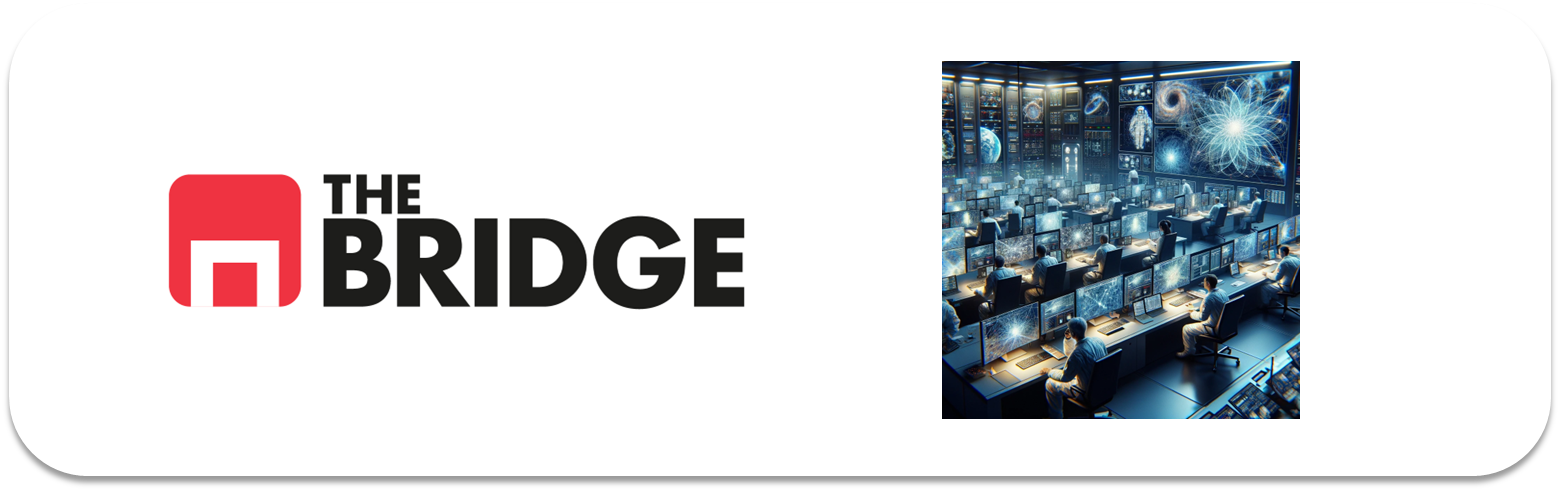

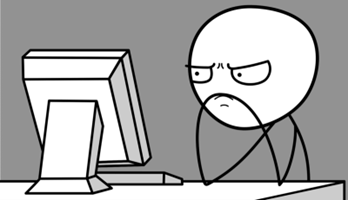

Para ejercitarte y afianzar lo aprendido sobre **Transfer Learning y Fine-tuning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

## Apple 360

En este conjunto de ejercicios vas a montar un clasificador de manzanas mediante un dataset de imágenes. El dataset se compone de 13 tipos diferentes con aproximadamente unas 200 imágenes por cada tipo. Tendrás que montar un modelo de deep learning que utilice **transfer learning**. Se sugiere empezar con una red ResNet50 con imagenet.

El dataset original proviene del [concurso de Kaggle Fruits 360](https://www.kaggle.com/moltean/fruits), pero adaptado para la clasificación de una menor cantidad de casos (sólo las manzanas).


### Ejercicio 1

Crea los juegos de X,y para train y test a partir de los datos teninendo en cuenta su distribución, para ello tendrás que explorar las estructura. Crea un juego Train,test para resolución 32x32 y un juego de test adicional para 224x224. Es decir tendras que tener un X_train, X_test para 32x32 y un X_test adicional a 224x224

In [1]:
import os
import numpy as np
from PIL import Image
import collections

# ------------------------------------------------------------------
# 1. Configuración de rutas y tamaños
# ------------------------------------------------------------------
BASE = "data/apples"
TRAIN_DIR = os.path.join(BASE, "Train")    # si tu carpeta se llama "training", cámbialo
TEST_DIR  = os.path.join(BASE, "Test")

SIZE_SMALL = (32, 32)
SIZE_LARGE = (224, 224)
EXT = (".jpg", ".jpeg", ".png", ".bmp")

# ------------------------------------------------------------------
# 2. Explorar estructura: clases + distribución por conjunto
# ------------------------------------------------------------------
clases = sorted(
    d for d in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, d))
)
class_to_idx = {c: i for i, c in enumerate(clases)}

print(f"Nº de clases: {len(clases)}\n")
for split_name, split_dir in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR)]:
    print(f"--- {split_name} ---")
    for c in clases:
        n = len([f for f in os.listdir(os.path.join(split_dir, c))
                 if f.lower().endswith(EXT)])
        print(f"  {c:15s} -> {n}")
    print()

# ------------------------------------------------------------------
# 3. Función reutilizable: carga un directorio de clases a un tamaño dado
# ------------------------------------------------------------------
def cargar_directorio(directorio, size, class_to_idx, ext=EXT):
    X, y = [], []
    for c, idx in class_to_idx.items():
        carpeta = os.path.join(directorio, c)
        for f in os.listdir(carpeta):
            if f.lower().endswith(ext):
                img = Image.open(os.path.join(carpeta, f)).convert("RGB").resize(size)
                X.append(np.asarray(img, dtype=np.uint8))
                y.append(idx)
    return np.array(X, dtype=np.uint8), np.array(y)

# ------------------------------------------------------------------
# 4. Construir los juegos pedidos
# ------------------------------------------------------------------
# Resolución 32x32 -> train y test
X_train, y_train = cargar_directorio(TRAIN_DIR, SIZE_SMALL, class_to_idx)
X_test,  y_test  = cargar_directorio(TEST_DIR,  SIZE_SMALL, class_to_idx)

# Resolución 224x224 -> solo el test adicional (mismas imágenes que X_test)
X_test_224, y_test_224 = cargar_directorio(TEST_DIR, SIZE_LARGE, class_to_idx)

# ------------------------------------------------------------------
# 5. Verificación
# ------------------------------------------------------------------
print("Formas resultantes:")
print(f"  X_train      (32x32):   {X_train.shape}")
print(f"  X_test       (32x32):   {X_test.shape}")
print(f"  X_test_224  (224x224):  {X_test_224.shape}")
print(f"  y_train:                {y_train.shape}")
print(f"  y_test:                 {y_test.shape}")

# y_test y y_test_224 deben ser idénticos (mismo directorio, mismo orden)
print(f"\n¿y_test == y_test_224?  {np.array_equal(y_test, y_test_224)}")
print("Distribución test:", dict(collections.Counter(y_test)))

Nº de clases: 13

--- TRAIN ---
  Braeburn        -> 492
  CrimsonSnow     -> 444
  Golden1         -> 480
  Golden2         -> 492
  Golden3         -> 481
  GrannySmith     -> 492
  PinkLady        -> 456
  Red1            -> 492
  Red2            -> 492
  Red3            -> 429
  RedDelicious    -> 490
  RedYellow1      -> 492
  RedYellow2      -> 672

--- TEST ---
  Braeburn        -> 164
  CrimsonSnow     -> 148
  Golden1         -> 160
  Golden2         -> 164
  Golden3         -> 161
  GrannySmith     -> 164
  PinkLady        -> 152
  Red1            -> 164
  Red2            -> 164
  Red3            -> 144
  RedDelicious    -> 166
  RedYellow1      -> 164
  RedYellow2      -> 219

Formas resultantes:
  X_train      (32x32):   (6404, 32, 32, 3)
  X_test       (32x32):   (2134, 32, 32, 3)
  X_test_224  (224x224):  (2134, 224, 224, 3)
  y_train:                (6404,)
  y_test:                 (2134,)

¿y_test == y_test_224?  True
Distribución test: {np.int64(0): 164, np.int64(1): 

**NOTA:** A partir de aquí emplea siempre el X_train, X_test de 32x32 salvo en el ejercicio que se te diga lo contrario.

### Ejercicio 2

Haz una visualización de algunos de los datos. Crea una función que te ayude con ello.

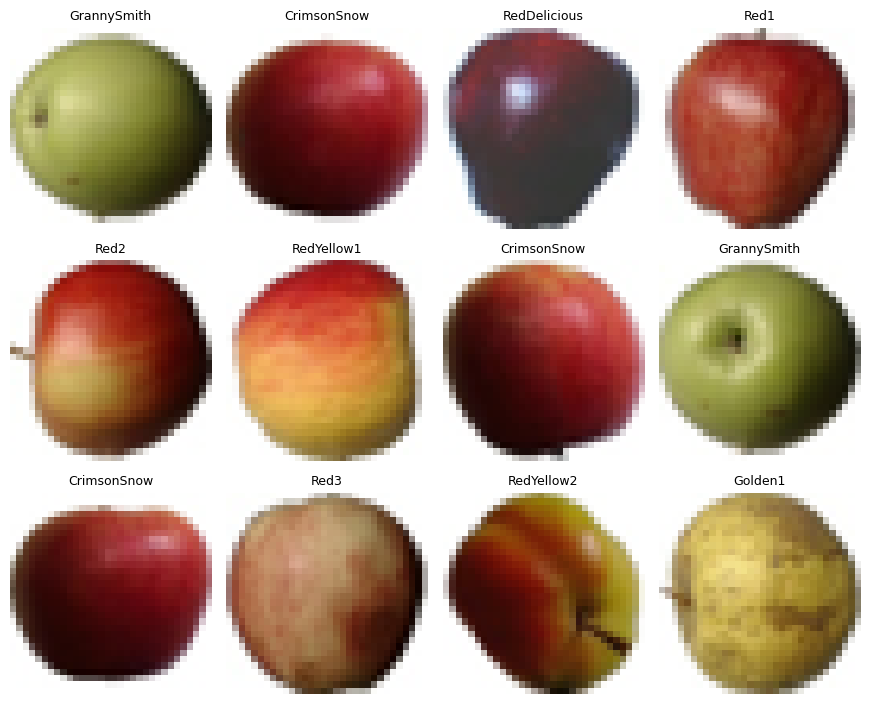

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Mapa inverso índice -> nombre de clase (para poner títulos legibles)
idx_to_class = {i: c for c, i in class_to_idx.items()}

def visualizar_muestras(X, y, idx_to_class, n=12, cols=4, aleatorio=True, seed=None):
    """
    Muestra una cuadrícula de imágenes con su etiqueta.

    X          : array de imágenes (n, alto, ancho, 3)
    y          : array de etiquetas enteras
    idx_to_class : dict {índice: nombre_clase}
    n          : nº de imágenes a mostrar
    cols       : nº de columnas de la cuadrícula
    aleatorio  : si True elige índices al azar; si False, los n primeros
    seed       : semilla para reproducir la selección aleatoria
    """
    if aleatorio:
        rng = np.random.default_rng(seed)
        indices = rng.choice(len(X), size=n, replace=False)
    else:
        indices = np.arange(n)

    filas = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 2.2, filas * 2.4))

    for pos, i in enumerate(indices):
        plt.subplot(filas, cols, pos + 1)
        plt.imshow(X[i])                       # uint8 0-255, se ve directo
        plt.title(idx_to_class[y[i]], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# --- Uso ---
# 12 imágenes aleatorias del train (32x32)
visualizar_muestras(X_train, y_train, idx_to_class, n=12, cols=4, seed=42)

### Ejercicio 3

Completa el miniEDA habitual con imágenes y escoge una métrica para el modelo.

--- TRAIN 32x32 ---
  Nº imágenes:      6404
  Dimensión imagen: 32x32, canales: 3
  dtype:            uint8
  Rango de píxeles: [0, 255]
  Nº de clases:     13
  Memoria (MB):     19.7

--- TEST 32x32 ---
  Nº imágenes:      2134
  Dimensión imagen: 32x32, canales: 3
  dtype:            uint8
  Rango de píxeles: [0, 255]
  Nº de clases:     13
  Memoria (MB):     6.6



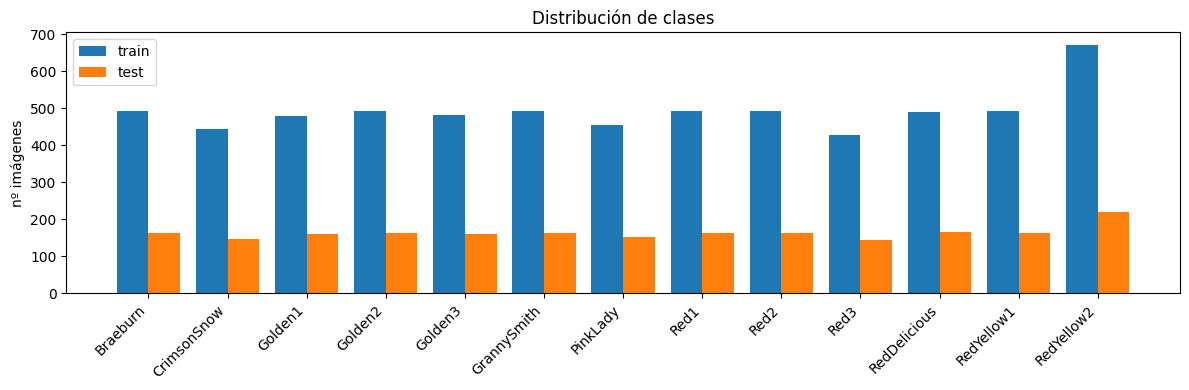

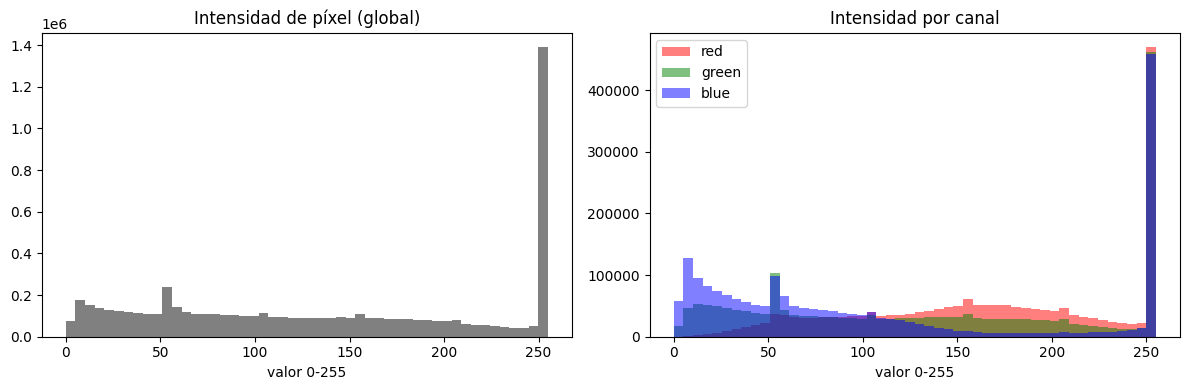

Media por canal (R,G,B): [168.8 138.2 110. ]
Std  por canal (R,G,B): [68.6 86.7 92.5]


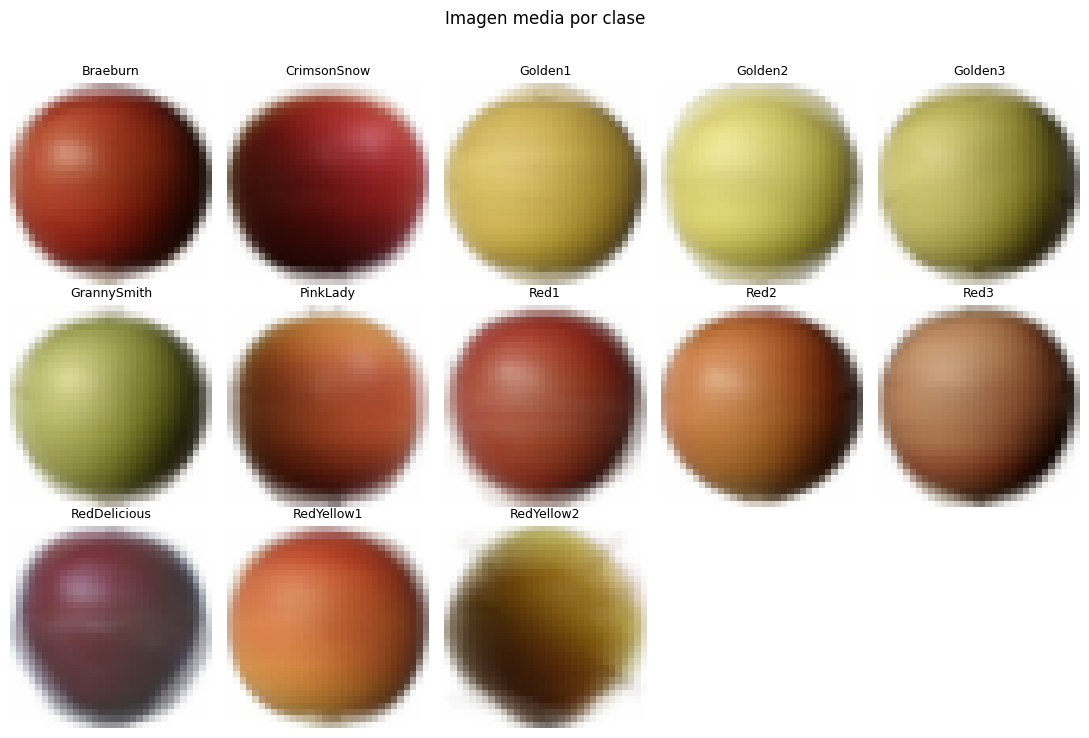

Imágenes constantes (posible corrupción): 0
Rango real: [0, 255]
Duplicados exactos: 0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import collections

idx_to_class = {i: c for c, i in class_to_idx.items()}

# ==================================================================
# 1. Resumen numérico básico
# ==================================================================
def resumen_dataset(X, y, nombre=""):
    print(f"--- {nombre} ---")
    print(f"  Nº imágenes:      {X.shape[0]}")
    print(f"  Dimensión imagen: {X.shape[1]}x{X.shape[2]}, canales: {X.shape[3]}")
    print(f"  dtype:            {X.dtype}")
    print(f"  Rango de píxeles: [{X.min()}, {X.max()}]")
    print(f"  Nº de clases:     {len(np.unique(y))}")
    print(f"  Memoria (MB):     {X.nbytes / 1e6:.1f}")
    print()

resumen_dataset(X_train, y_train, "TRAIN 32x32")
resumen_dataset(X_test,  y_test,  "TEST 32x32")


# ==================================================================
# 2. Distribución de clases (visual): train vs test
# ==================================================================
def plot_distribucion(y_train, y_test, idx_to_class):
    clases = sorted(idx_to_class.keys())
    nombres = [idx_to_class[i] for i in clases]
    cnt_tr = collections.Counter(y_train)
    cnt_te = collections.Counter(y_test)

    x = np.arange(len(clases))
    ancho = 0.4
    plt.figure(figsize=(12, 4))
    plt.bar(x - ancho/2, [cnt_tr[i] for i in clases], ancho, label="train")
    plt.bar(x + ancho/2, [cnt_te[i] for i in clases], ancho, label="test")
    plt.xticks(x, nombres, rotation=45, ha="right")
    plt.ylabel("nº imágenes")
    plt.title("Distribución de clases")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_distribucion(y_train, y_test, idx_to_class)


# ==================================================================
# 3. Distribución de intensidades de píxel (global y por canal RGB)
# ==================================================================
def plot_intensidades(X, muestra=2000, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=min(muestra, len(X)), replace=False)
    sub = X[idx].reshape(-1, 3)   # (n_pixeles, 3)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(sub.ravel(), bins=50, color="gray")
    plt.title("Intensidad de píxel (global)")
    plt.xlabel("valor 0-255")

    plt.subplot(1, 2, 2)
    for c, col in zip(range(3), ["red", "green", "blue"]):
        plt.hist(sub[:, c], bins=50, alpha=0.5, color=col, label=col)
    plt.title("Intensidad por canal")
    plt.xlabel("valor 0-255")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Media por canal (R,G,B):", sub.mean(axis=0).round(1))
    print("Std  por canal (R,G,B):", sub.std(axis=0).round(1))

plot_intensidades(X_train)


# ==================================================================
# 4. Imagen media por clase (el "prototipo" visual de cada tipo)
# ==================================================================
def plot_imagen_media(X, y, idx_to_class, cols=5):
    clases = sorted(idx_to_class.keys())
    filas = int(np.ceil(len(clases) / cols))
    plt.figure(figsize=(cols * 2.2, filas * 2.4))
    for pos, idx in enumerate(clases):
        media = X[y == idx].mean(axis=0).astype(np.uint8)
        plt.subplot(filas, cols, pos + 1)
        plt.imshow(media)
        plt.title(idx_to_class[idx], fontsize=9)
        plt.axis("off")
    plt.suptitle("Imagen media por clase", y=1.02)
    plt.tight_layout()
    plt.show()

plot_imagen_media(X_train, y_train, idx_to_class)


# ==================================================================
# 5. Comprobaciones de sanidad
# ==================================================================
def chequeos(X, y):
    # imágenes constantes (todo negro / todo blanco / un solo color)
    constantes = np.sum([np.all(img == img.flat[0]) for img in X])
    print(f"Imágenes constantes (posible corrupción): {constantes}")

    # ¿algún valor fuera de 0-255? (no debería con uint8)
    print(f"Rango real: [{X.min()}, {X.max()}]")

    # duplicados exactos (hash rápido por bytes)
    hashes = [hash(img.tobytes()) for img in X]
    dups = len(hashes) - len(set(hashes))
    print(f"Duplicados exactos: {dups}")

chequeos(X_train, y_train)

### Elección de métrica — Apple 360

**Métrica principal: Accuracy**

Justificación:

- Es un problema de **clasificación multiclase** (13 clases) con **una etiqueta por imagen**. La accuracy (proporción de aciertos) es la métrica natural y la más interpretable para comunicar el resultado.
- El **desbalance es leve** (ratio ~1,57× entre la clase mayor, RedYellow2 con 672, y la menor, Red3 con 429). Con un desbalance tan suave, la accuracy no queda distorsionada de forma relevante, por lo que es válida como número de referencia.

**Métricas de apoyo (diagnóstico): F1 macro + matriz de confusión**

- **F1 macro**: promedia el F1 de cada clase por igual, sin ponderar por tamaño. Si una clase minoritaria (Red3, CrimsonSnow) rinde mal, el F1 macro lo penaliza aunque la accuracy global apenas se mueva. Detecta lo que la accuracy puede enmascarar.
- **Matriz de confusión**: identifica *entre qué clases concretas* falla el modelo. El EDA anticipa que el error se concentrará en el cluster de variedades rojas/naranjas (Braeburn, CrimsonSnow, Red1, PinkLady, Red2, Red3, RedYellow1), cuyos prototipos son casi idénticos a 32×32.

**Implementación**

- Durante el entrenamiento: `metrics=["accuracy"]` en `model.compile` para monitorizar.
- En la evaluación sobre test: `classification_report` y `confusion_matrix` de scikit-learn para obtener F1 macro, F1 por clase y el detalle de confusiones.

**Si el enunciado pide una única métrica:** la respuesta es **accuracy**, justificada por el balance razonable entre clases. F1 macro y matriz de confusión son herramientas de análisis complementarias, no la métrica de optimización.

### Ejercicio 4 

Termina de transformar los datos si crees que es conveniente y aunque el entrenamiento de modelos de keras ya tiene un shuffling interno, haz un "barajado" del X_train (del X_test no es necesario) para facilitar la convergencia inicial del modelo. Utiliza la función shuffle de sklearn y asigna la salida a un X_train distinto (es decir no machaques el inicial)

In [4]:
import numpy as np
from sklearn.utils import shuffle

# ------------------------------------------------------------------
# Barajado del TRAIN (el TEST no se toca)
# Se barajan X_train e y_train JUNTOS -> misma permutación, se conserva
# la correspondencia imagen<->etiqueta. Salida a variables NUEVAS.
# ------------------------------------------------------------------
X_train_shuffled, y_train_shuffled = shuffle(X_train, y_train, random_state=42)

# ------------------------------------------------------------------
# Comprobaciones
# ------------------------------------------------------------------
# 1) Los originales siguen intactos
print("X_train original intacto:", X_train.shape, "| primeras etiquetas:", y_train[:10])

# 2) El barajado tiene mismas formas pero distinto orden
print("X_train_shuffled:", X_train_shuffled.shape, "| primeras etiquetas:", y_train_shuffled[:10])
print("¿El orden ha cambiado?", not np.array_equal(y_train, y_train_shuffled))  # True

# 3) La correspondencia X<->y se mantiene: el conteo por clase es idéntico
import collections
print("Distribución original:", dict(sorted(collections.Counter(y_train).items())))
print("Distribución barajado:", dict(sorted(collections.Counter(y_train_shuffled).items())))

X_train original intacto: (6404, 32, 32, 3) | primeras etiquetas: [0 0 0 0 0 0 0 0 0 0]
X_train_shuffled: (6404, 32, 32, 3) | primeras etiquetas: [ 5 11  5  2 10  5  4  1 10  9]
¿El orden ha cambiado? True
Distribución original: {np.int64(0): 492, np.int64(1): 444, np.int64(2): 480, np.int64(3): 492, np.int64(4): 481, np.int64(5): 492, np.int64(6): 456, np.int64(7): 492, np.int64(8): 492, np.int64(9): 429, np.int64(10): 490, np.int64(11): 492, np.int64(12): 672}
Distribución barajado: {np.int64(0): 492, np.int64(1): 444, np.int64(2): 480, np.int64(3): 492, np.int64(4): 481, np.int64(5): 492, np.int64(6): 456, np.int64(7): 492, np.int64(8): 492, np.int64(9): 429, np.int64(10): 490, np.int64(11): 492, np.int64(12): 672}


### Ejercicio 5

Sklearn permite trabajar con etiquetas textuales pero keras no. Transforma las etiquetas a numéricas, creando dos diccionarios uno que permita traducir de etiqueta a clase numérica y otro que permita la transformación inversa.

In [5]:
# ------------------------------------------------------------------
# Dos diccionarios de traducción de etiquetas
# ------------------------------------------------------------------
# 1) etiqueta textual -> clase numérica   (para preparar datos hacia Keras)
label_to_num = {nombre: i for i, nombre in enumerate(clases)}

# 2) clase numérica -> etiqueta textual   (para interpretar las predicciones)
num_to_label = {i: nombre for nombre, i in label_to_num.items()}

# ------------------------------------------------------------------
# Comprobación
# ------------------------------------------------------------------
print("label_to_num:", label_to_num)
print("num_to_label:", num_to_label)

# Verificar que son inversos exactos entre sí
ok = all(num_to_label[label_to_num[c]] == c for c in clases)
print("\n¿Los diccionarios son inversos exactos?", ok)

# Ejemplos de uso
print("\n'GrannySmith' ->", label_to_num["GrannySmith"])
print("5 ->", num_to_label[5])

# Traducir las primeras etiquetas del train barajado a texto
print("\ny_train_shuffled[:5]:", y_train_shuffled[:5])
print("en texto:", [num_to_label[i] for i in y_train_shuffled[:5]])

label_to_num: {'Braeburn': 0, 'CrimsonSnow': 1, 'Golden1': 2, 'Golden2': 3, 'Golden3': 4, 'GrannySmith': 5, 'PinkLady': 6, 'Red1': 7, 'Red2': 8, 'Red3': 9, 'RedDelicious': 10, 'RedYellow1': 11, 'RedYellow2': 12}
num_to_label: {0: 'Braeburn', 1: 'CrimsonSnow', 2: 'Golden1', 3: 'Golden2', 4: 'Golden3', 5: 'GrannySmith', 6: 'PinkLady', 7: 'Red1', 8: 'Red2', 9: 'Red3', 10: 'RedDelicious', 11: 'RedYellow1', 12: 'RedYellow2'}

¿Los diccionarios son inversos exactos? True

'GrannySmith' -> 5
5 -> GrannySmith

y_train_shuffled[:5]: [ 5 11  5  2 10]
en texto: ['GrannySmith', 'RedYellow1', 'GrannySmith', 'Golden1', 'RedDelicious']


### Ejercicio 6: Zero Shot Learning

Descar el modelo ResNet50 preparado ya para poder usarlo directamente a la Zero Shot Learning. Pruébalo contra el test (aquí no valen nuestras categorías serán las que proporcione ResNet ojo). Prueba una selección aleatoria de imágenes del test y compara las etiquetas de ResNet con la que tiene. ¿Nos sirve este clasificador así tal cual?

Real (nuestra)     | ResNet (ImageNet)      | prob
----------------------------------------------------------
GrannySmith        | Granny_Smith           | 0.99
CrimsonSnow        | pomegranate            | 0.41
RedDelicious       | punching_bag           | 0.19
Red1               | strawberry             | 0.13
Red2               | fig                    | 0.53
RedYellow1         | spaghetti_squash       | 0.49
CrimsonSnow        | pomegranate            | 0.34
GrannySmith        | Granny_Smith           | 0.99
CrimsonSnow        | pomegranate            | 0.33
Red3               | fig                    | 0.62
RedYellow2         | Granny_Smith           | 0.42
Golden1            | spaghetti_squash       | 0.98


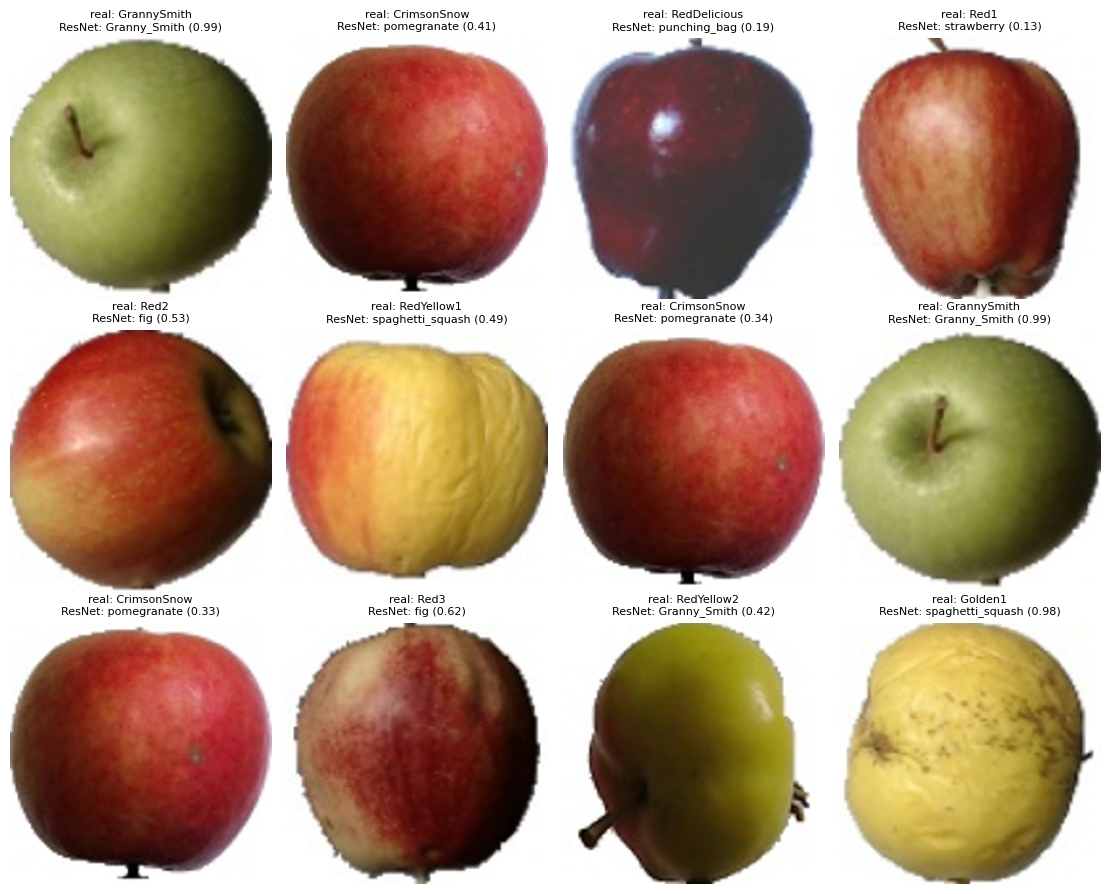

In [6]:
from tensorflow.keras.applications.resnet50 import (
    ResNet50, preprocess_input, decode_predictions
)

# ------------------------------------------------------------------
# 1. Modelo COMPLETO con cabeza de clasificación ImageNet (1000 clases)
#    include_top=True -> devuelve las categorías de ImageNet, no las nuestras
# ------------------------------------------------------------------
model_zs = ResNet50(weights="imagenet", include_top=True)   # espera 224x224x3

# ------------------------------------------------------------------
# 2. Selección aleatoria de imágenes del TEST a 224x224
# ------------------------------------------------------------------
rng = np.random.default_rng(42)
n = 12
idx = rng.choice(len(X_test_224), size=n, replace=False)

muestras = X_test_224[idx].astype("float32")
muestras_pre = preprocess_input(muestras.copy())   # preprocesado propio de ResNet (espera 0-255)

# ------------------------------------------------------------------
# 3. Predicción zero-shot + decodificación a etiquetas ImageNet
# ------------------------------------------------------------------
preds = model_zs.predict(muestras_pre, verbose=0)
top = decode_predictions(preds, top=1)             # top-1 de ImageNet

# ------------------------------------------------------------------
# 4. Comparar etiqueta REAL (nuestra) vs etiqueta de ResNet (ImageNet)
# ------------------------------------------------------------------
print(f"{'Real (nuestra)':18s} | {'ResNet (ImageNet)':22s} | prob")
print("-" * 58)
for k, i in enumerate(idx):
    real = num_to_label[y_test[i]]
    _, nombre_in, prob = top[k][0]
    print(f"{real:18s} | {nombre_in:22s} | {prob:.2f}")

# ------------------------------------------------------------------
# 5. Visualización con ambas etiquetas
# ------------------------------------------------------------------
filas = int(np.ceil(n / 4))
plt.figure(figsize=(4 * 2.8, filas * 3))
for k, i in enumerate(idx):
    plt.subplot(filas, 4, k + 1)
    plt.imshow(X_test_224[i].astype("uint8"))
    real = num_to_label[y_test[i]]
    _, nombre_in, prob = top[k][0]
    plt.title(f"real: {real}\nResNet: {nombre_in} ({prob:.2f})", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Ejercicio 6 — Zero-Shot con ResNet50: ¿nos sirve tal cual?

**Respuesta: NO sirve como clasificador de variedades de manzana.**

**El problema es el vocabulario de salida, no la calidad del modelo.**
ResNet50 con `include_top=True` predice sobre las **1000 categorías de ImageNet**. De todas ellas, solo **una** es una manzana concreta: `Granny_Smith`. Las otras 12 variedades del dataset no existen como categoría en ImageNet, así que es **imposible por construcción** que el modelo las acierte.

**Lo que se observa en la muestra aleatoria del test:**
- **GrannySmith → `Granny_Smith` (0.99)**: único acierto real, y solo porque esa clase sí está en ImageNet.
- **Variedades rojas → `pomegranate`, `fig`, `strawberry`**: el modelo elige el "vecino visual" (fruta roja/redonda) dentro de su vocabulario.
- **Variedades amarillas → `spaghetti_squash`**: mismo efecto por color.
- **RedDelicious → `punching_bag`**: error grosero por forma oscura y brillante.
- Un caso engañoso: una RedYellow2 verde etiquetada `Granny_Smith` (0.42) → acierta la palabra por color, no por variedad.

**Conclusión:** el fallo no es de precisión, es de **desajuste de espacio de salida**. El clasificador zero-shot responde en un vocabulario (ImageNet) que no coincide con el problema (13 variedades de manzana).

**Motivación del siguiente paso — transfer learning:**
Se conserva la **base convolucional** de ResNet50 (el extractor de características, que sí ha aprendido bordes, texturas y formas útiles, como demuestra que agrupe bien por color/forma) y se **sustituye la cabeza** de 1000 clases de ImageNet por una nueva de **13 salidas**, entrenada con nuestros datos. Aprovechamos las features buenas y adaptamos solo el clasificador final.

## Transfer Learning

### Ejercicio 7:

Carga la ResNet50 sin cabezas, crea un modelo con el anterior y una cabeza con dos capas densas, una oculta de 300 unidades (con activación "relu") y otra de salida con las unidades que crees necesarias y activación la que consideres. Congela las capas del modelo base (la ResNet50). Define también los hiperparámetros necesarios para compilar y compila el modelo y muestra un summary del mismo.

In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

# ------------------------------------------------------------------
# 1. Hiperparámetros
# ------------------------------------------------------------------
IMG_SIZE = (224, 224, 3)     # ResNet50 espera esta entrada
N_CLASES = 13                # nuestras 13 variedades de manzana
UNIDADES_OCULTAS = 300       # capa densa oculta (según enunciado)
LR = 1e-3                    # learning rate para Adam
ACT_OCULTA = "relu"
ACT_SALIDA = "softmax"       # multiclase, una etiqueta por imagen

In [8]:
# ------------------------------------------------------------------
# 2. Base ResNet50 SIN cabeza (include_top=False)
#    pooling="avg" -> aplica GlobalAveragePooling y devuelve un vector
#    plano (None, 2048), listo para conectar a capas densas.
# ------------------------------------------------------------------
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE,
    pooling="avg"
)

In [9]:
# ------------------------------------------------------------------
# 3. Congelar TODAS las capas de la base
#    No se actualizarán en el entrenamiento: solo entrenamos la cabeza.
# ------------------------------------------------------------------
base_model.trainable= False

In [10]:
# ------------------------------------------------------------------
# 4. Modelo completo = base congelada + cabeza nueva
# ------------------------------------------------------------------
model = models.Sequential([
    base_model,
    layers.Dense(UNIDADES_OCULTAS, activation=ACT_OCULTA),
    layers.Dense(N_CLASES, activation=ACT_SALIDA)
])

In [11]:
# ------------------------------------------------------------------
# 5. Compilar
#    Etiquetas enteras (0-12) -> sparse_categorical_crossentropy
# ------------------------------------------------------------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
# ------------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------------
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       614,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         3,913 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,206,325 (92.34 MB)

 Trainable params: 618,613 (2.36 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

### Ejercicio 8

Entrena el modelo con nuestros datos de train y muestra la evolución del entrenamiento. Emplea un callback de Earlystopping con patience a 5. Termina de escoger el batch_size y el número de épocas.

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks

# ------------------------------------------------------------------
# 1. Hiperparámetros
# ------------------------------------------------------------------
IMG_SIZE_32 = (32, 32, 3)   # <-- entrenamos a 32x32 (regla vigente + solo hay train a 32x32)
N_CLASES = 13
UNIDADES_OCULTAS = 300
LR = 1e-3
BATCH_SIZE = 32             # equilibrio memoria/estabilidad del gradiente
EPOCHS = 30                 # techo alto; EarlyStopping cortará antes
PATIENCE = 5


In [14]:
# ------------------------------------------------------------------
# 2. Construcción del modelo
# ------------------------------------------------------------------

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE_32,
    pooling="avg"
)

base_model.trainable = False    # base congelada

model = models.Sequential([
    base_model,
    layers.Dense(UNIDADES_OCULTAS, activation='relu'),
    layers.Dense(N_CLASES, activation='softmax')
])

model.compile(
    optimizer = optimizers.Adam(learning_rate=LR),
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# ------------------------------------------------------------------
# 3. Preprocesado propio de ResNet sobre el train BARAJADO
#    preprocess_input espera 0-255 -> pasamos a float32 y aplicamos
# ------------------------------------------------------------------
X_train_prep = preprocess_input(X_train_shuffled.astype("float32"))

In [16]:
# ------------------------------------------------------------------
# 4. Callback EarlyStopping (patience=5) + restaurar mejores pesos
# ------------------------------------------------------------------
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

In [19]:
# ------------------------------------------------------------------
# 5. Entrenamiento
#    validation_split=0.2 -> Keras separa el último 20% como validación.
#    Como X_train_shuffled YA está barajado, ese 20% es una muestra
#    representativa (aquí se ve para qué sirvió el shuffle del Ej4).
# ------------------------------------------------------------------
history = model.fit(
    X_train_prep, y_train_shuffled,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 24s 117ms/step - accuracy: 0.9159 - loss: 0.4115 - val_accuracy: 0.9914 - val_loss: 0.0257
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.9926 - loss: 0.0198 - val_accuracy: 0.9992 - val_loss: 0.0044
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 1.0000 - loss: 8.0745e-04 - val_accuracy: 0.9992 - val_loss: 0.0013
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 1.0000 - loss: 4.0078e-04 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.9998 - loss: 9.3519e-04 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 6/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 1.0000 - loss: 2.7100e-04 - val_accuracy: 1.0000 - val_loss: 6.4453e-04
Epoch 7/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 1.0000 - loss: 2.1738e-04 - val_accuracy: 1.0000 - val_loss: 8.2002e-04
Epoch 8/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step 

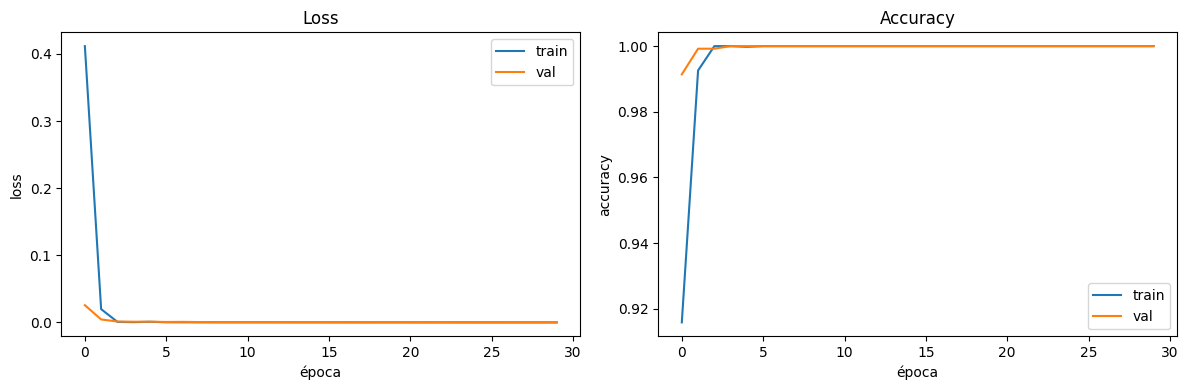

Épocas ejecutadas: 30 (de 30 máx.)
Mejor val_accuracy: 1.0000
Mejor val_loss:     0.0001


In [20]:
# ------------------------------------------------------------------
# 6. Evolución del entrenamiento
# ------------------------------------------------------------------
def plot_history(history):
    h = history.history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], label="val")
    plt.title("Loss"); plt.xlabel("época"); plt.ylabel("loss"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], label="val")
    plt.title("Accuracy"); plt.xlabel("época"); plt.ylabel("accuracy"); plt.legend()

    plt.tight_layout(); plt.show()

plot_history(history)

print(f"Épocas ejecutadas: {len(history.history['loss'])} (de {EPOCHS} máx.)")
print(f"Mejor val_accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Mejor val_loss:     {min(history.history['val_loss']):.4f}")

### Ejercicio 9

Evalua el modelo contra test y haz un pequeño análisis de las diferencias. Haz un clasification report y muestra la matriz de confusion. Haz un pequeño análisis de errores.

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [21]:
# ------------------------------------------------------------------
# 1. Preprocesado del TEST (mismo que en train) y evaluación global
# ------------------------------------------------------------------
X_test_prep = preprocess_input(X_test.astype("float32"))

test_loss, test_acc = model.evaluate(X_test_prep, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     0.3414
Test accuracy: 0.9306


In [23]:
# ------------------------------------------------------------------
# 2. Predicciones -> clase con mayor probabilidad
# ------------------------------------------------------------------
y_prob = model.predict(X_test_prep, batch_size=64, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# ------------------------------------------------------------------
# 3. Classification report (precision, recall, F1 por clase + macro)
# ------------------------------------------------------------------
nombres = [num_to_label[i] for i in range(N_CLASES)]
print("\n" + classification_report(y_test, y_pred, target_names=nombres, digits=3))



              precision    recall  f1-score   support

    Braeburn      0.750     0.915     0.824       164
 CrimsonSnow      0.953     0.953     0.953       148
     Golden1      1.000     1.000     1.000       160
     Golden2      1.000     1.000     1.000       164
     Golden3      1.000     1.000     1.000       161
 GrannySmith      1.000     1.000     1.000       164
    PinkLady      0.937     0.980     0.958       152
        Red1      0.723     0.970     0.828       164
        Red2      0.899     0.866     0.882       164
        Red3      0.927     0.354     0.513       144
RedDelicious      1.000     1.000     1.000       166
  RedYellow1      1.000     0.976     0.988       164
  RedYellow2      1.000     1.000     1.000       219

    accuracy                          0.931      2134
   macro avg      0.938     0.924     0.919      2134
weighted avg      0.939     0.931     0.924      2134



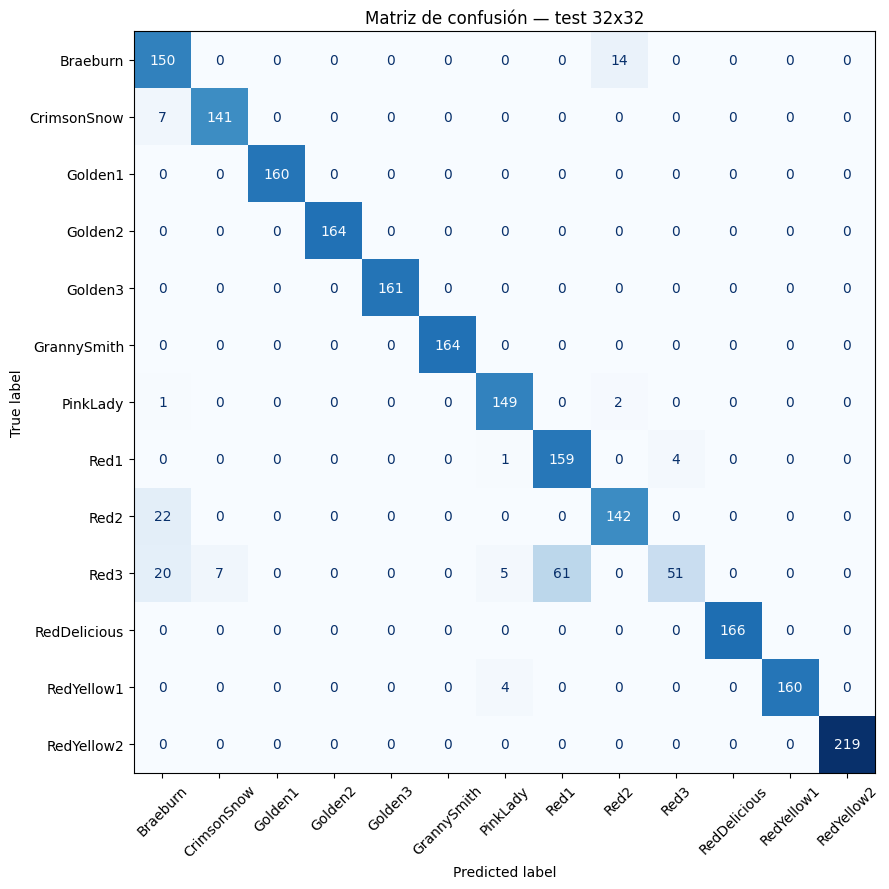

In [24]:
# ------------------------------------------------------------------
# 4. Matriz de confusión
# ------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — test 32x32")
plt.tight_layout()
plt.show()


In [25]:
# ------------------------------------------------------------------
# 5. Localizar los errores concretos (para el análisis)
# ------------------------------------------------------------------
errores = np.where(y_pred != y_test)[0]
print(f"\nNº de errores: {len(errores)} de {len(y_test)} "
      f"({100*len(errores)/len(y_test):.2f}%)")

# Desglose: qué confundió con qué
if len(errores) > 0:
    print("\nErrores (real -> predicho):")
    for i in errores:
        conf = y_prob[i, y_pred[i]]
        print(f"  {num_to_label[y_test[i]]:14s} -> {num_to_label[y_pred[i]]:14s} "
              f"(conf {conf:.2f})")



Nº de errores: 148 de 2134 (6.94%)

Errores (real -> predicho):
  Braeburn       -> Red2           (conf 0.51)
  Braeburn       -> Red2           (conf 0.78)
  Braeburn       -> Red2           (conf 0.89)
  Braeburn       -> Red2           (conf 0.91)
  Braeburn       -> Red2           (conf 0.90)
  Braeburn       -> Red2           (conf 0.90)
  Braeburn       -> Red2           (conf 0.95)
  Braeburn       -> Red2           (conf 0.95)
  Braeburn       -> Red2           (conf 0.94)
  Braeburn       -> Red2           (conf 0.97)
  Braeburn       -> Red2           (conf 0.91)
  Braeburn       -> Red2           (conf 0.78)
  Braeburn       -> Red2           (conf 0.84)
  Braeburn       -> Red2           (conf 0.65)
  CrimsonSnow    -> Braeburn       (conf 0.66)
  CrimsonSnow    -> Braeburn       (conf 0.49)
  CrimsonSnow    -> Braeburn       (conf 0.63)
  CrimsonSnow    -> Braeburn       (conf 0.58)
  CrimsonSnow    -> Braeburn       (conf 0.54)
  CrimsonSnow    -> Braeburn       (conf 0

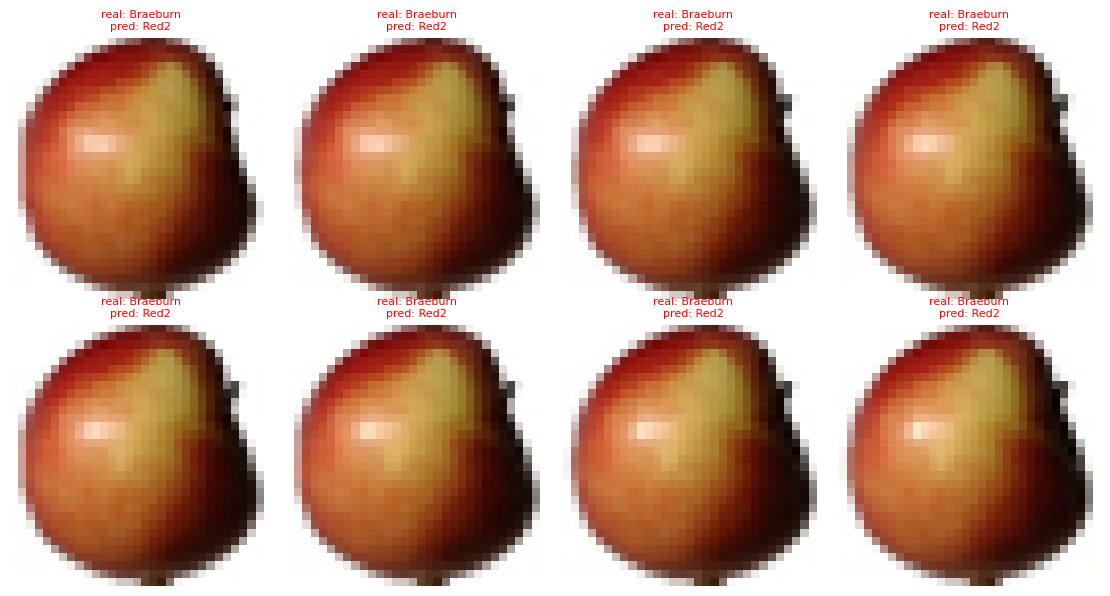

In [26]:
# ------------------------------------------------------------------
# 6. Visualizar algunos errores (si los hay)
# ------------------------------------------------------------------
if len(errores) > 0:
    n_ver = min(8, len(errores))
    sel = errores[:n_ver]
    filas = int(np.ceil(n_ver / 4))
    plt.figure(figsize=(4 * 2.8, filas * 3))
    for k, i in enumerate(sel):
        plt.subplot(filas, 4, k + 1)
        plt.imshow(X_test[i].astype("uint8"))
        plt.title(f"real: {num_to_label[y_test[i]]}\n"
                  f"pred: {num_to_label[y_pred[i]]}", fontsize=8, color="red")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("\nSin errores: el modelo acertó todo el test.")

## Ejercicio 9 — Evaluación en test: análisis

**Métricas globales:** accuracy 0.931 | F1 macro 0.919 | 148 errores / 2134 (6.94%)

**Diferencia validación vs test:** el modelo pasó de val_accuracy = 1.00 a test accuracy = 0.931. La caída es la señal esperada: la validación salía del mismo conjunto de fotos que el train (misma fruta rotada), mientras que el test son piezas independientes. El 93% es la métrica honesta.

**El error está 100% localizado en el cluster de variedades rojas**, tal como anticipó la imagen media del EDA. Las clases de color singular (Golden1/2/3, GrannySmith, RedDelicious, RedYellow2) tienen F1 = 1.000 sin una sola confusión.

**Caso crítico — Red3 (recall 0.354):** solo se aciertan 51 de 144. El grueso se fuga a Red1 (61 casos), muchos con confianza 0.95–1.00. No es duda, es información perdida: a 32×32 Red3 y Red1 son indistinguibles.

**Confusiones principales (todas dentro del bloque rojo, y simétricas):**
- Braeburn ↔ Red2 (mutua, alta confianza)
- Red3 → Red1 / Braeburn / CrimsonSnow (masiva)
- CrimsonSnow → Braeburn
- RedYellow1 → PinkLady

**Precision vs recall divergentes:** Red1 (recall 0.97 / precision 0.72) absorbe predicciones ajenas; Red3 (precision 0.93 / recall 0.35) se vacía hacia Red1. Caras opuestas del mismo solapamiento.

**Interpretación de fondo:** el fallo no es del modelo ni del entrenamiento (limpio, sin overfitting), sino de la **resolución**. A 32×32 se pierde la textura fina (moteado, vetas, brillos) que es lo único que separa las variedades rojas entre sí. El color basta para 8 clases; las otras 5 necesitan detalle espacial.

**Hipótesis para el siguiente paso:** evaluar a 224×224 debería recuperar gran parte de ese 7% perdido, porque a esa resolución sí sobrevive la textura que distingue Red1/Red2/Red3/Braeburn. Ahí se justifica haber cargado X_test_224.

## Fine Tuning

### Ejercicio 10

Vuelve a descargar el modelo ResNet50 pero sin pesos entrenados, ni cabeza, crea el mismo modelo personalizado que en el ejercicio 7, compila y muestra el summary.

In [27]:
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

# ------------------------------------------------------------------
# 1. Hiperparámetros (mismos que el Ej7)
# ------------------------------------------------------------------
IMG_SIZE_32 = (32, 32, 3)    # coherente con nuestro X_train de 32x32
N_CLASES = 13
UNIDADES_OCULTAS = 300
LR = 1e-3

# ------------------------------------------------------------------
# 2. ResNet50 SIN pesos entrenados (weights=None) y SIN cabeza
#    weights=None -> pesos aleatorios, NO ImageNet
#    include_top=False + pooling="avg" -> salida plana (None, 2048)
# ------------------------------------------------------------------
base_model_ft = ResNet50(
    weights=None,             # <-- clave: sin preentrenar
    include_top=False,
    input_shape=IMG_SIZE_32,
    pooling="avg"
)

# ------------------------------------------------------------------
# 3. NO se congela: toda la red es entrenable
#    (sin pesos preentrenados, congelar no tendría sentido)
# ------------------------------------------------------------------
base_model_ft.trainable = True

# ------------------------------------------------------------------
# 4. Mismo modelo personalizado que en el Ej7
# ------------------------------------------------------------------
model_ft = models.Sequential([
    base_model_ft,
    layers.Dense(UNIDADES_OCULTAS, activation="relu"),
    layers.Dense(N_CLASES, activation="softmax"),
])

# ------------------------------------------------------------------
# 5. Compilar (mismos hiperparámetros que el Ej7)
# ------------------------------------------------------------------
model_ft.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------------
model_ft.summary()

entrenables = np.sum([np.prod(w.shape) for w in model_ft.trainable_weights])
congelados  = np.sum([np.prod(w.shape) for w in model_ft.non_trainable_weights])
print(f"\nParámetros entrenables: {entrenables:,}")
print(f"Parámetros congelados:  {congelados:,}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │       614,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │         3,913 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,206,325 (92.34 MB)

 Trainable params: 24,153,205 (92.14 MB)

 Non-trainable params: 53,120 (207.50 KB)


Parámetros entrenables: 24,153,205
Parámetros congelados:  53,120


### Ejercicio 11
Entrena con batch_size a 64 y 60 épocas, con un EarlyStopping de patience a 10 (ahora el entrenamiento es sensiblemente más largo, así que tómate un descanso). Muestra la evolución y da una posible justificación a emplear tantas épocas de partida.

In [28]:
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks
from tensorflow.keras.applications.resnet50 import preprocess_input

# ------------------------------------------------------------------
# 1. Hiperparámetros pedidos
# ------------------------------------------------------------------
BATCH_SIZE = 64
EPOCHS = 60
PATIENCE = 10

# ------------------------------------------------------------------
# 2. Preprocesado del train barajado (si no lo tienes ya en memoria)
#    Nota: con weights=None el preprocess_input de ResNet no es
#    estrictamente necesario, pero lo mantenemos para que la entrada
#    sea idéntica a la del modelo del Ej7-9 y la comparación sea justa.
# ------------------------------------------------------------------
X_train_prep = preprocess_input(X_train_shuffled.astype("float32"))

# ------------------------------------------------------------------
# 3. EarlyStopping con patience=10
# ------------------------------------------------------------------
early_stop_ft = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True
)

# ------------------------------------------------------------------
# 4. Entrenamiento
# ------------------------------------------------------------------
history_ft = model_ft.fit(
    X_train_prep, y_train_shuffled,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop_ft],
    verbose=1
)

# ------------------------------------------------------------------
# 5. Evolución del entrenamiento
# ------------------------------------------------------------------
def plot_history(history, titulo=""):
    h = history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], label="val")
    plt.title(f"Loss {titulo}"); plt.xlabel("época"); plt.ylabel("loss"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h["accuracy"], label="train")
    plt.plot(h["val_accuracy"], label="val")
    plt.title(f"Accuracy {titulo}"); plt.xlabel("época"); plt.ylabel("accuracy"); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(history_ft, "(ResNet50 desde cero)")

print(f"Épocas ejecutadas: {len(history_ft.history['loss'])} (de {EPOCHS} máx.)")
print(f"Mejor val_accuracy: {max(history_ft.history['val_accuracy']):.4f}")
print(f"Mejor val_loss:     {min(history_ft.history['val_loss']):.4f}")

Epoch 1/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.8349 - loss: 0.6901 - val_accuracy: 0.1163 - val_loss: 2.8211
Epoch 2/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8657 - loss: 0.4278 - val_accuracy: 0.2490 - val_loss: 2.4083
Epoch 3/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.8823 - loss: 0.3780 - val_accuracy: 0.1624 - val_loss: 5.9868
Epoch 4/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9289 - loss: 0.2451 - val_accuracy: 0.3661 - val_loss: 3.4970
Epoch 5/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9664 - loss: 0.1005 - val_accuracy: 0.8017 - val_loss: 0.6037
Epoch 6/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9836 - loss: 0.0701 - val_accuracy: 0.7338 - val_loss: 1.0724
Epoch 7/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9889 - loss: 0.0415 - val_accuracy: 0.8525 - val_loss: 0.4448
Epoch 8/60
81/81 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.9678 - loss: 0.1111 - val_accuracy: 0.4059 - val_los

KeyboardInterrupt: 

### Ejercicio 12

Muestra la evaluación contra el test, el informe de clasificación  y la matriz de confusión. Compara los resultados con los del ejercicio 9.